In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


PARTIE 1 — Installation

In [2]:
!pip install ultralytics
!pip install torchmetrics
!pip install opencv-python
!pip install tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.3 MB/s eta 0:00:00


PARTIE 2 — Import

In [3]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from torch.utils.data import DataLoader
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


PARTIE 3 — Télécharger Pascal VOC

In [4]:
import torchvision.datasets as datasets
import torchvision.transforms as T


transform = T.Compose([
    T.ToTensor()
])


train_dataset = datasets.VOCDetection(
    root="./data",
    year="2007",
    image_set="train",
    download=True,
    transform=transform
)


val_dataset = datasets.VOCDetection(
    root="./data",
    year="2007",
    image_set="val",
    download=True,
    transform=transform
)


print(len(train_dataset))
print(len(val_dataset))

100%|██████████| 460M/460M [00:17<00:00, 26.3MB/s]


2501
2510


PARTIE 4 — Créer un SUBSET rapide GPU

In [5]:
from torch.utils.data import Subset

train_size = 1000
val_size = 200


train_dataset = Subset(
    train_dataset,
    range(train_size)
)


val_dataset = Subset(
    val_dataset,
    range(val_size)
)


print(len(train_dataset))
print(len(val_dataset))

1000
200


PARTIE 5 — YOLOv8n

In [6]:
import os

folders=[
"results/yolo",
"results/fasterrcnn",
"results/graphs",
"results/models"
]


for f in folders:
    os.makedirs(f,exist_ok=True)

print("folders created")

folders created


In [7]:
from ultralytics import YOLO
import time
import pandas as pd


optimizers=[
"SGD",
"AdamW",
"RMSProp"
]


yolo_results=[]


def train_yolo(opt):

    print("Training YOLO with",opt)

    model=YOLO("yolov8n.pt")


    start=time.time()


    result=model.train(
        data="VOC.yaml",
        epochs=3,
        imgsz=416,
        batch=16,
        optimizer=opt,
        device=0,
        project="results/yolo",
        name=opt
    )


    train_time=time.time()-start


    metrics=model.val()


    yolo_results.append({

        "Model":"YOLOv8n",
        "Optimizer":opt,
        "mAP50":metrics.box.map50,
        "mAP50-95":metrics.box.map,
        "Precision":metrics.box.mp,
        "Recall":metrics.box.mr,
        "Training_time":train_time

    })



for opt in optimizers:
    train_yolo(opt)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Training YOLO with SGD
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

In [8]:
yolo_final = pd.DataFrame(yolo_results)

In [9]:
yolo_final.to_csv(
"results/yolo/yolo_final_comparison.csv",
index=False
)

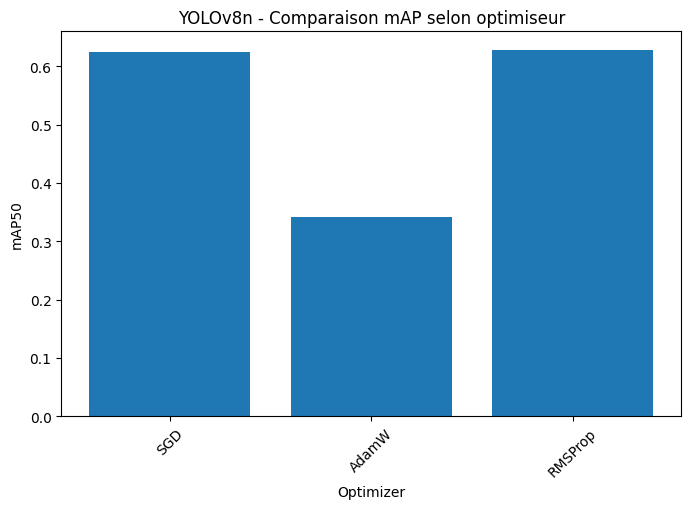

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.bar(
yolo_final["Optimizer"],
yolo_final["mAP50"]
)


plt.title("YOLOv8n - Comparaison mAP selon optimiseur")

plt.xlabel("Optimizer")

plt.ylabel("mAP50")


plt.xticks(rotation=45)

plt.show()

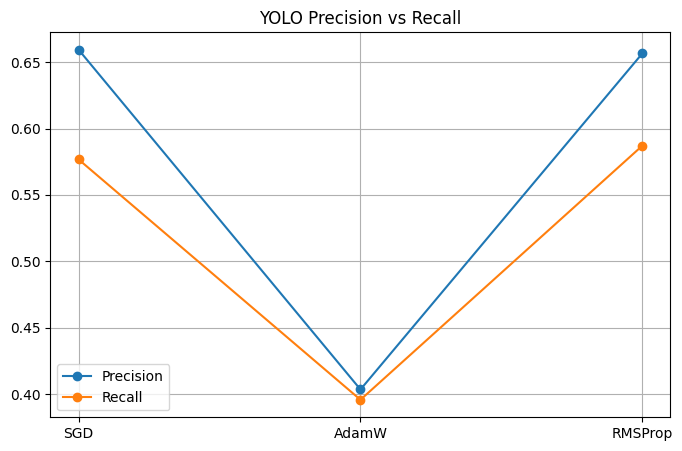

In [11]:
x=yolo_final["Optimizer"]


plt.figure(figsize=(8,5))


plt.plot(
x,
yolo_final["Precision"],
marker="o",
label="Precision"
)


plt.plot(
x,
yolo_final["Recall"],
marker="o",
label="Recall"
)


plt.title("YOLO Precision vs Recall")

plt.legend()

plt.grid()

plt.show()

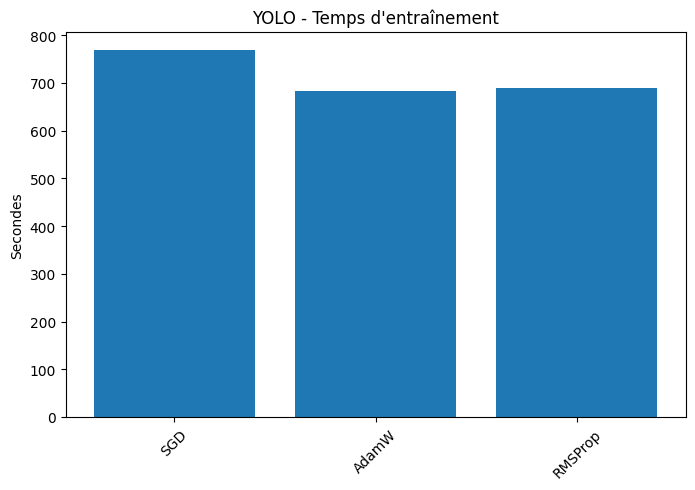

In [12]:
plt.figure(figsize=(8,5))


plt.bar(
yolo_final["Optimizer"],
yolo_final["Training_time"]
)


plt.title(
"YOLO - Temps d'entraînement"
)


plt.ylabel("Secondes")


plt.xticks(rotation=45)

plt.show()

In [13]:
yolo_final.style.background_gradient(
subset=["mAP50","Precision","Recall"]
)

,Model,Optimizer,mAP50,mAP50-95,Precision,Recall,Training_time
0,YOLOv8n,SGD,0.624859,0.419519,0.659362,0.576700,768.702878
1,YOLOv8n,AdamW,0.341731,0.202569,0.403388,0.395641,682.718346
2,YOLOv8n,RMSProp,0.628183,0.425988,0.656567,0.587054,689.146608


Faster R-CNN

In [14]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from torch.utils.data import DataLoader, Subset

from torchvision.datasets import VOCDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [16]:
train_dataset_full = VOCDetection(
    root="./data",
    year="2012",
    image_set="train",
    download=True
)

val_dataset_full = VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=True
)

100%|██████████| 2.00G/2.00G [01:12<00:00, 27.7MB/s]


In [17]:
print(len(train_dataset_full))
print(len(val_dataset_full))

5717
5823


In [18]:
train_indices = random.sample(
    range(len(train_dataset_full)),
    1000
)

val_indices = random.sample(
    range(len(val_dataset_full)),
    200
)

train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    val_dataset_full,
    val_indices
)

print(len(train_dataset))
print(len(val_dataset))

1000
200


In [19]:
from PIL import Image
from torchvision.transforms import functional as F

VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat",
    "bottle","bus","car","cat","chair",
    "cow","diningtable","dog","horse",
    "motorbike","person","pottedplant",
    "sheep","sofa","train","tvmonitor"
]

CLASS_DICT = {
    name:i+1
    for i,name in enumerate(VOC_CLASSES)
}

In [20]:
class VOCDataset(torch.utils.data.Dataset):

    def __init__(self, subset):

        self.subset = subset

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, idx):

        image, target = self.subset[idx]

        image = F.to_tensor(image)

        objects = target["annotation"]["object"]

        if not isinstance(objects, list):
            objects = [objects]

        boxes = []
        labels = []

        for obj in objects:

            bbox = obj["bndbox"]

            xmin = float(bbox["xmin"])
            ymin = float(bbox["ymin"])
            xmax = float(bbox["xmax"])
            ymax = float(bbox["ymax"])

            boxes.append(
                [xmin, ymin, xmax, ymax]
            )

            labels.append(
                CLASS_DICT[obj["name"]]
            )

        boxes = torch.tensor(
            boxes,
            dtype=torch.float32
        )

        labels = torch.tensor(
            labels,
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

In [21]:
train_dataset = VOCDataset(train_dataset)

val_dataset = VOCDataset(val_dataset)

In [25]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [26]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [27]:
images, targets = next(iter(train_loader))

print(len(images))
print(targets[0].keys())

4
dict_keys(['boxes', 'labels'])


In [28]:
images, targets = next(iter(train_loader))

print(len(images))
print(targets[0].keys())
print(targets[0]["boxes"].shape)

4
dict_keys(['boxes', 'labels'])
torch.Size([3, 4])


In [29]:
import os

os.makedirs("results/fasterrcnn", exist_ok=True)

In [30]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

model.to(device)

print("Model loaded")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 84.4MB/s]


Model loaded


In [31]:
images, targets = next(iter(train_loader))

images = [img.to(device) for img in images]

targets = [
    {k:v.to(device) for k,v in t.items()}
    for t in targets
]

model.train()

loss_dict = model(images, targets)

print(loss_dict)

{'loss_classifier': tensor(1.5322, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1715, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0094, device='cuda:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0106, device='cuda:0', grad_fn=<DivBackward0>)}


In [32]:
def train_frcnn(optimizer_name):

    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name == "SGD":

        optimizer = torch.optim.SGD(
            params,
            lr=0.005,
            momentum=0.9,
            weight_decay=0.0005
        )

    elif optimizer_name == "AdamW":

        optimizer = torch.optim.AdamW(
            params,
            lr=1e-4
        )

    elif optimizer_name == "RMSProp":

        optimizer = torch.optim.RMSprop(
            params,
            lr=1e-4
        )

    losses = []

    start_time = time.time()

    for epoch in range(3):

        model.train()

        epoch_loss = 0

        for images, targets in train_loader:

            images = [img.to(device) for img in images]

            targets = [
                {k:v.to(device) for k,v in t.items()}
                for t in targets
            ]

            loss_dict = model(images, targets)

            loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)

        print(
            f"{optimizer_name} | Epoch {epoch+1}/3 | Loss = {epoch_loss:.3f}"
        )

    training_time = time.time() - start_time

    return model, losses, training_time

In [33]:
def measure_fps(model):

    model.eval()

    start = time.time()

    with torch.no_grad():

        for images, _ in val_loader:

            images = [img.to(device) for img in images]

            _ = model(images)

    total = time.time() - start

    fps = len(val_loader.dataset) / total

    return fps

In [34]:
model_sgd, losses_sgd, train_time_sgd = train_frcnn("SGD")

fps_sgd = measure_fps(model_sgd)

print("FPS :", fps_sgd)
print("Training time :", train_time_sgd)

SGD | Epoch 1/3 | Loss = 117.164
SGD | Epoch 2/3 | Loss = 74.080
SGD | Epoch 3/3 | Loss = 57.025
FPS : 6.458336061643968
Training time : 1041.8731582164764


In [35]:
model_adamw, losses_adamw, train_time_adamw = train_frcnn("AdamW")

fps_adamw = measure_fps(model_adamw)

print("FPS :", fps_adamw)
print("Training time :", train_time_adamw)

AdamW | Epoch 1/3 | Loss = 125.204
AdamW | Epoch 2/3 | Loss = 88.274
AdamW | Epoch 3/3 | Loss = 71.587
FPS : 6.522509845336904
Training time : 1036.617103099823


In [36]:
mmodel_rms, losses_rms, train_time_rms = train_frcnn("RMSProp")

fps_rms = measure_fps(model_rms)

print("FPS :", fps_rms)
print("Training time :", train_time_rms)

RMSProp | Epoch 1/3 | Loss = 181.940
RMSProp | Epoch 2/3 | Loss = 132.032
RMSProp | Epoch 3/3 | Loss = 107.911


NameError: name 'model_rms' is not defined

In [37]:
fps_rms = measure_fps(mmodel_rms)

print("FPS :", fps_rms)
print("Training time :", train_time_rms)

FPS : 6.3654247177357295
Training time : 1026.6579036712646


In [38]:
%whos

Variable                  Type            Data/Info
---------------------------------------------------
CLASS_DICT                dict            n=20
DataLoader                type            <class 'torch.utils.data.dataloader.DataLoader'>
F                         module          <module 'torchvision.tran<...>ransforms/functional.py'>
Image                     module          <module 'PIL.Image' from <...>t-packages/PIL/Image.py'>
Subset                    type            <class 'torch.utils.data.dataset.Subset'>
T                         module          <module 'torchvision.tran<...>/transforms/__init__.py'>
VOCDataset                type            <class '__main__.VOCDataset'>
VOCDetection              type            <class 'torchvision.datasets.voc.VOCDetection'>
VOC_CLASSES               list            n=20
YOLO                      type            <class 'ultralytics.models.yolo.model.YOLO'>
collate_fn                function        <function collate_fn at 0x7e6929ad7d80>
da

In [40]:
results = pd.DataFrame({

    "Optimizer":[
        "SGD",
        "AdamW",
        "RMSProp"
    ],

    "Final_Loss":[
        losses_sgd[-1],
        losses_adamw[-1],
        losses_rms[-1]
    ],

    "Training_Time":[
        train_time_sgd,
        train_time_adamw,
        train_time_rms
    ],

    "FPS":[
        fps_sgd,
        fps_adamw,
        fps_rms
    ]

})

results

,Optimizer,Final_Loss,Training_Time,FPS
0,SGD,57.024828,1041.873158,6.458336
1,AdamW,71.586740,1036.617103,6.522510
2,RMSProp,107.910984,1026.657904,6.365425


In [41]:
results.to_csv(
    "results/fasterrcnn/fasterrcnn_results.csv",
    index=False
)

print("Saved")

Saved


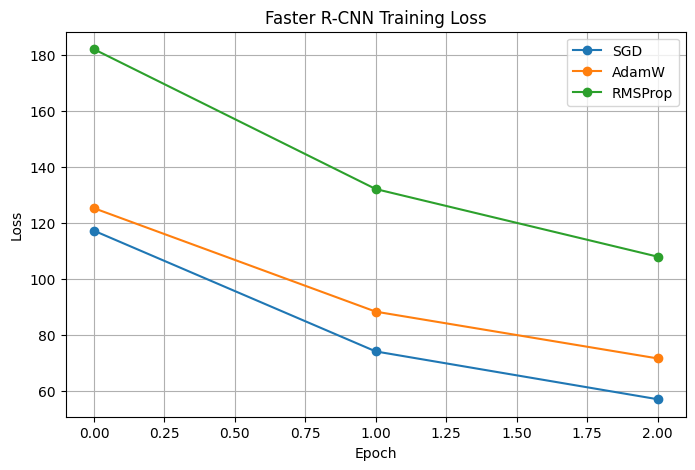

In [42]:
plt.figure(figsize=(8,5))

plt.plot(losses_sgd, marker='o', label='SGD')
plt.plot(losses_adamw, marker='o', label='AdamW')
plt.plot(losses_rms, marker='o', label='RMSProp')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN Training Loss")

plt.legend()

plt.grid()

plt.show()

In [47]:
import pandas as pd

frcnn_df = pd.DataFrame({

    "Optimizer": ["SGD", "AdamW", "RMSProp"],

    "Final_Loss": [
        losses_sgd[-1],
        losses_adamw[-1],
        losses_rms[-1]
    ],

    "Training_Time": [
        train_time_sgd,
        train_time_adamw,
        train_time_rms
    ],

    "FPS": [
        fps_sgd,
        fps_adamw,
        fps_rms
    ]
})

frcnn_df

,Optimizer,Final_Loss,Training_Time,FPS
0,SGD,57.024828,1041.873158,6.458336
1,AdamW,71.586740,1036.617103,6.522510
2,RMSProp,107.910984,1026.657904,6.365425


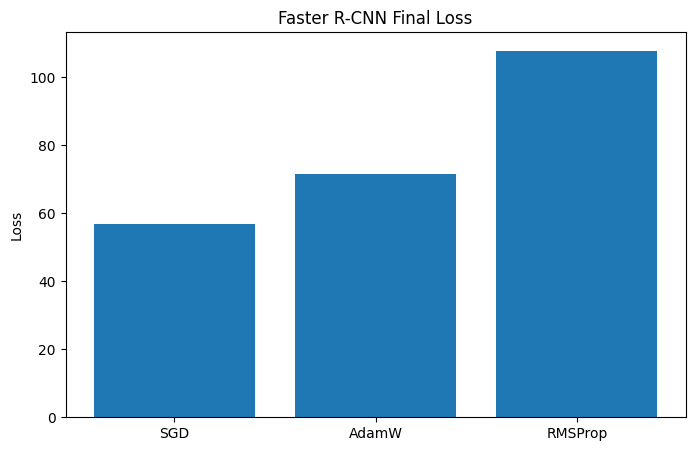

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["Final_Loss"]
)

plt.title("Faster R-CNN Final Loss")
plt.ylabel("Loss")

plt.show()

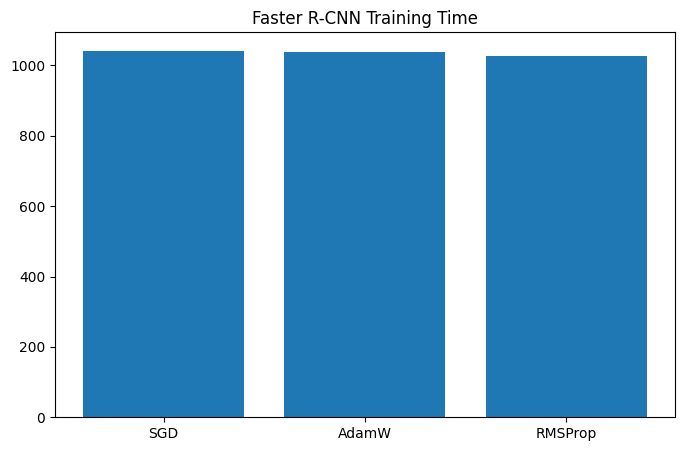

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    frcnn_df["Optimizer"],
    frcnn_df["Training_Time"]
)

plt.title("Faster R-CNN Training Time")
plt.show()

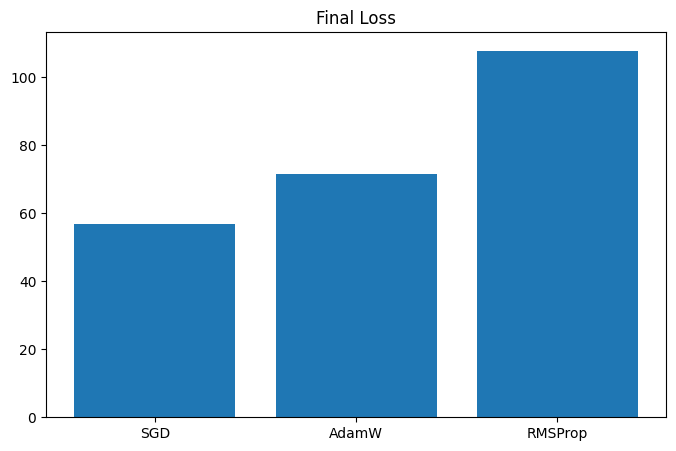

In [51]:
plt.figure(figsize=(8,5))
plt.bar(frcnn_df["Optimizer"], frcnn_df["Final_Loss"])
plt.title("Final Loss")
plt.show()

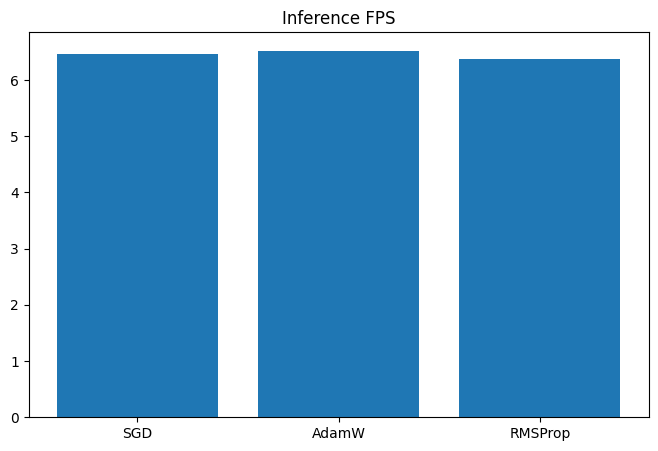

In [52]:
plt.figure(figsize=(8,5))
plt.bar(frcnn_df["Optimizer"], frcnn_df["FPS"])
plt.title("Inference FPS")
plt.show()

COMPARAISON FINALE YOLO vs Faster R-CNN

In [53]:
import pandas as pd

yolo_df = pd.read_csv("results/yolo/yolo_final_comparison.csv")
frcnn_df = pd.read_csv("results/fasterrcnn/fasterrcnn_results.csv")

In [54]:
yolo_df["Model"] = "YOLOv8n"
frcnn_df["Model"] = "Faster R-CNN"

final_df = pd.concat([yolo_df, frcnn_df], ignore_index=True)

final_df

,Model,Optimizer,mAP50,mAP50-95,Precision,Recall,Training_time,Final_Loss,Training_Time,FPS
0,YOLOv8n,SGD,0.624859,0.419519,0.659362,0.576700,768.702878,NaN,NaN,NaN
1,YOLOv8n,AdamW,0.341731,0.202569,0.403388,0.395641,682.718346,NaN,NaN,NaN
2,YOLOv8n,RMSProp,0.628183,0.425988,0.656567,0.587054,689.146608,NaN,NaN,NaN
3,Faster R-CNN,SGD,NaN,NaN,NaN,NaN,NaN,57.024828,1041.873158,6.458336
4,Faster R-CNN,AdamW,NaN,NaN,NaN,NaN,NaN,71.586740,1036.617103,6.522510
5,Faster R-CNN,RMSProp,NaN,NaN,NaN,NaN,NaN,107.910984,1026.657904,6.365425


In [55]:
final_df.sort_values(["Model", "Optimizer"])

,Model,Optimizer,mAP50,mAP50-95,Precision,Recall,Training_time,Final_Loss,Training_Time,FPS
4,Faster R-CNN,AdamW,NaN,NaN,NaN,NaN,NaN,71.586740,1036.617103,6.522510
5,Faster R-CNN,RMSProp,NaN,NaN,NaN,NaN,NaN,107.910984,1026.657904,6.365425
3,Faster R-CNN,SGD,NaN,NaN,NaN,NaN,NaN,57.024828,1041.873158,6.458336
1,YOLOv8n,AdamW,0.341731,0.202569,0.403388,0.395641,682.718346,NaN,NaN,NaN
2,YOLOv8n,RMSProp,0.628183,0.425988,0.656567,0.587054,689.146608,NaN,NaN,NaN
0,YOLOv8n,SGD,0.624859,0.419519,0.659362,0.576700,768.702878,NaN,NaN,NaN


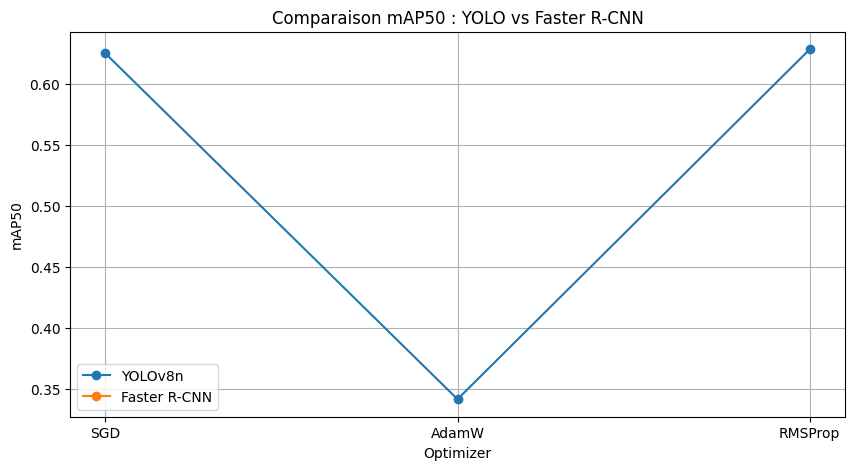

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.plot(
        data["Optimizer"],
        data["mAP50"],
        marker="o",
        label=model
    )

plt.title("Comparaison mAP50 : YOLO vs Faster R-CNN")
plt.xlabel("Optimizer")
plt.ylabel("mAP50")
plt.legend()
plt.grid()
plt.show()

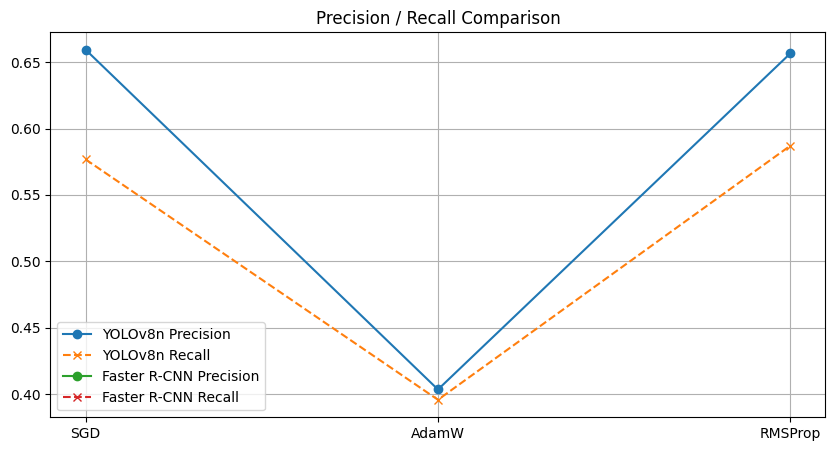

In [57]:
plt.figure(figsize=(10,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.plot(data["Optimizer"], data["Precision"], marker="o", label=f"{model} Precision")
    plt.plot(data["Optimizer"], data["Recall"], marker="x", linestyle="--", label=f"{model} Recall")

plt.title("Precision / Recall Comparison")
plt.legend()
plt.grid()
plt.show()

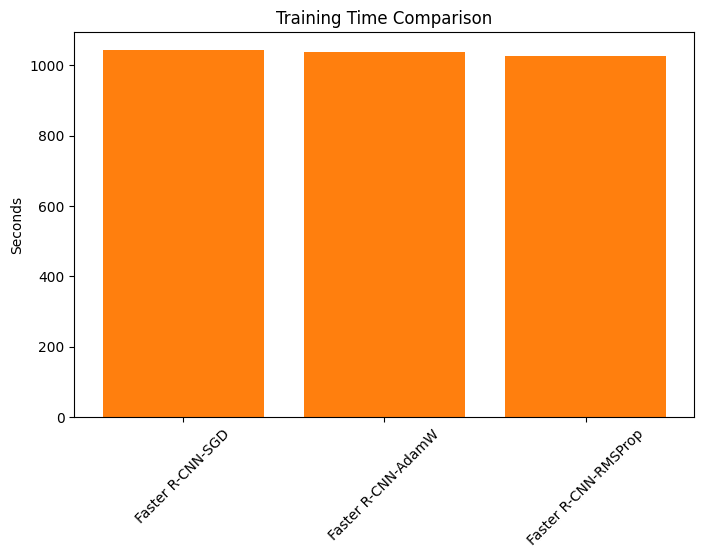

In [58]:
plt.figure(figsize=(8,5))

for model in final_df["Model"].unique():

    data = final_df[final_df["Model"] == model]

    plt.bar(
        [f"{model}-{opt}" for opt in data["Optimizer"]],
        data["Training_Time"],
        label=model
    )

plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.ylabel("Seconds")
plt.show()

In [61]:
final_report = final_df[[
    "Model",
    "Optimizer",
    "mAP50",
    "Precision",
    "Recall",
    "Training_Time"
]]

final_report

,Model,Optimizer,mAP50,Precision,Recall,Training_Time
0,YOLOv8n,SGD,0.624859,0.659362,0.576700,NaN
1,YOLOv8n,AdamW,0.341731,0.403388,0.395641,NaN
2,YOLOv8n,RMSProp,0.628183,0.656567,0.587054,NaN
3,Faster R-CNN,SGD,NaN,NaN,NaN,1041.873158
4,Faster R-CNN,AdamW,NaN,NaN,NaN,1036.617103
5,Faster R-CNN,RMSProp,NaN,NaN,NaN,1026.657904
